Calculates NI spatial and temporal on CGA dateset

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.signal import detrend, butter, filtfilt
import matplotlib.pyplot as plt

def compute_spatial_nsi(markers: xr.DataArray,
                        window_samples: int = 500,
                        fs: float = 100.0) -> dict:
    """
    
     1) Extract 'COM' channel, transpose to dims ('time','axis')
     2) Detrend y-axis (AP) with a 0.1 Hz high-pass filter
     3) (Optional) anchor the filtered AP so it starts at zero
     4) Compute NSI separately for x, y, z using non-overlapping windows of size `window_samples`

    Parameters
    ----------
    markers : xr.DataArray
        DataArray with dims ('axis','channel','time') and a channel named 'COM'.
    window_samples : int
        Number of time-samples in each non-overlapping window for NSI.
    fs : float
        Sampling rate (Hz) of the COM time series.

    Returns
    -------
    dict
        Spatial NSI for each axis: {'x': val, 'y': val, 'z': val}
    """
    # 1) Extract COM channel and reorder dims → (time, axis)
    com = markers.sel(channel='COM').transpose('time', 'axis')
    data = com.values.copy()  # shape: (time, axis)

    # 2) High-pass filter on AP (y) at 0.1 Hz (cutting out drifts > 10 s)
    hp_cutoff = 0.1  # Hz
    b, a = butter(4, hp_cutoff / (fs / 2), btype='highpass')
    axes = [str(a).lower() for a in com.axis.values]
    if 'y' not in axes:
        raise ValueError(f"AP axis 'y' not found in channels: {com.axis.values}")
    y_idx = axes.index('y')
    data[:, y_idx] = filtfilt(b, a, data[:, y_idx])

    # 3) Anchor AP (y) to start at zero
    data[:, y_idx] -= data[0, y_idx]

    # 4) Rebuild the detrended/filtered COM DataArray
    com_dt = xr.DataArray(data, coords=com.coords, dims=com.dims)

    # Optional: visualize detrended AP
    plt.figure(figsize=(8, 4))
    plt.plot(com_dt.sel(axis='y').values, label="Filtered AP (y)")
    plt.title("High-Pass Filtered AP (y) Trace")
    plt.xlabel("Sample")
    plt.ylabel("Position (detrended)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 5) NSI helper on a 1D array
    def nsi(ts: np.ndarray, w: int) -> float:
        n = len(ts)
        if n < w or np.std(ts, ddof=1) == 0:
            return np.nan
        block_means = [ts[i:i+w].mean() for i in range(0, n - w + 1, w)]
        return np.std(block_means, ddof=1) / np.std(ts, ddof=1)

    # 6) Print window info for the user
    N = com_dt.sizes['time']
    M = (N - window_samples) // window_samples + 1
    print(f"COM series length: {N} samples ({N/fs:.2f} s)")
    print(f"Window size:       {window_samples} samples ({window_samples/fs:.2f} s)")
    print(f"Number of windows: {M}")

    # 7) Compute NSI per axis (no further trimming needed after HP filter)
    results = {}
    for ax in com_dt.axis.values:
        arr = com_dt.sel(axis=ax).values
        results[ax] = nsi(arr, window_samples)

    return results
def compute_temporal_nsi_from_events(events_df: pd.DataFrame,
                                     strides_per_window: int = 10,
                                     trim_strides: int = 5,
                                     outlier_thresh: float = 3.0) -> float:
    """
    Compute temporal NSI over the full trial from a CSV of events.

    Expects columns:
      - time: float (event timestamp, in seconds)
      - leg:  str   ('Left' or 'Right')
      - event: str  (e.g. 'Foot Strike')

    Steps:
      1) Keep only rows where event == 'Foot Strike'
      2) Extract timestamps for Left vs. Right
      3) Compute per-side stride intervals (diff of successive times)
      4) Pool Left+Right intervals into one array
      5) Trim the first/last `trim_strides` intervals (belt ramp artifacts)
      6) Discard intervals beyond ± outlier_thresh × SD
      7) NSI = SD(non-overlapping block-means) / SD(full interval series)

    Parameters
    ----------
    events_df : pd.DataFrame
        Must contain columns ['time','leg','event'].
        'leg' should be 'Left' or 'Right'. 'event' should include 'Foot Strike'.
    strides_per_window : int
        Number of strides in each non-overlapping window for NSI.
    trim_strides : int
        Number of strides to drop at start and end to avoid transients.
    outlier_thresh : float
        Discard any interval that is farther than ± outlier_thresh × SD from the mean.

    Returns
    -------
    float
        Temporal NSI for the pooled stride-time series.
    """
    # 1) Keep only Foot Strike rows
    df_fs = events_df[events_df['label'] == 'Foot Strike'].copy()

    # 2) Sorted timestamp arrays by leg
    tL = np.sort(df_fs.loc[df_fs['context'] == 'Left',  'time'].values)
    tR = np.sort(df_fs.loc[df_fs['context'] == 'Right', 'time'].values)

    # 3) Compute stride intervals per side
    strides_L = np.diff(tL)
    strides_R = np.diff(tR)

    # 4) Pool into one array
    all_strides = np.concatenate([strides_L, strides_R])

    # 5) Trim first/last trim_strides to drop belt ramp-up/down
    if len(all_strides) > 2 * trim_strides:
        all_strides = all_strides[trim_strides:-trim_strides]

    # 6) Remove outliers beyond ± outlier_thresh × SD
    mu, sigma = all_strides.mean(), all_strides.std(ddof=1)
    mask = np.abs(all_strides - mu) <= outlier_thresh * sigma
    all_strides = all_strides[mask]

    # 7) NSI helper: std of non-overlapping window-means / std of full series
    def nsi(ts: np.ndarray, k: int) -> float:
        n = len(ts)
        if n < k or np.std(ts, ddof=1) == 0:
            return np.nan
        block_means = [ts[i:i + k].mean() for i in range(0, n - k + 1, k)]
        return np.std(block_means, ddof=1) / np.std(ts, ddof=1)

    return nsi(all_strides, strides_per_window)


# def compute_temporal_nsi(events_df: pd.DataFrame,
#                                    strides_per_window: int = 10,
#                                    trim_strides: int = 2,
#                                    outlier_thresh: float = np.inf) -> float:
#     """
#     Compute Temporal NSI for a treadmill trial with a single perturbation.
#     Keeps the perturbation strides, but trims only the first/last `trim_strides`.
#     Does NOT remove outliers around the perturbation.
#     """
#     # 1) Foot Strike events only
#     df_fs = events_df[events_df['label'] == 'Foot Strike'].copy()

#     # 2) Sorted Left/Right times → intervals
#     tL = np.sort(df_fs[df_fs['context']=='Left' ].time.values)
#     tR = np.sort(df_fs[df_fs['context']=='Right'].time.values)
#     strides_L = np.diff(tL)
#     strides_R = np.diff(tR)

#     # 3) Pool
#     all_strides = np.concatenate([strides_L, strides_R])

#     # 4) Trim only treadmill start/end (keep the perturbation)
#     if len(all_strides) > 2*trim_strides:
#         all_strides = all_strides[trim_strides : -trim_strides]

#     # 5) No outlier removal (outlier_thresh=np.inf), so perturbation remains:
#     if outlier_thresh < np.inf:
#         mu, sigma = all_strides.mean(), all_strides.std(ddof=1)
#         mask = np.abs(all_strides - mu) <= outlier_thresh * sigma
#         all_strides = all_strides[mask]

#     # 6) NSI helper
#     def nsi(ts, k):
#         n = len(ts)
#         if n < k or np.std(ts, ddof=1) == 0:
#             return np.nan
#         block_means = [ts[i:i+k].mean() for i in range(0, n - k + 1, k)]
#         return np.std(block_means, ddof=1) / np.std(ts, ddof=1)

#     # 7) Compute NSI (the perturbation stride contributes to one block mean)
#     return nsi(all_strides, strides_per_window)




Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Markers DataArray loaded with shape: (3, 117, 5019)
Events DataFrame loaded with shape: (200, 4)
Temporal NSI: 0.28601772281426263


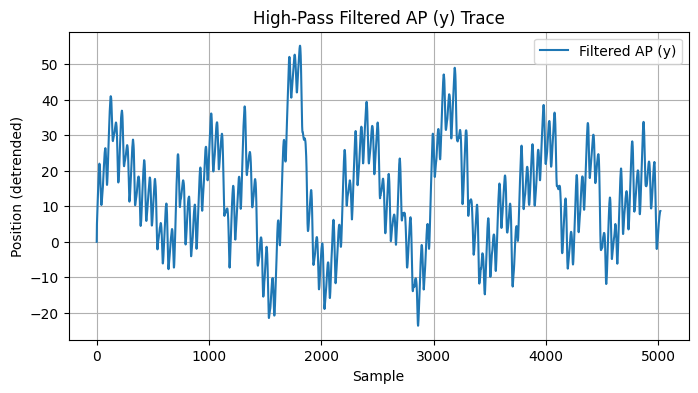

COM series length: 5019 samples (50.19 s)
Window size:       500 samples (5.00 s)
Number of windows: 10
Spatial NSI: {np.str_('x'): np.float64(0.722188651002247), np.str_('y'): np.float64(0.33056531914518605), np.str_('z'): np.float64(0.05057931687737174)}
Spatial NSI for x: 0.722188651002247
Spatial NSI for y: 0.33056531914518605
Spatial NSI for z: 0.05057931687737174


In [13]:

from pathlib import Path
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())

data_path = cwd.parent / ".." /"data"/"CGA"/"04"/"FWS"/"4"/"markers.nc"
events_path  = cwd.parent / ".." /"data"/"CGA"/"04"/"FWS"/"4"/"FWS.4_events.csv"


ds_CGA_04 = xr.open_dataarray(data_path)
print("Markers DataArray loaded with shape:", ds_CGA_04.shape)
df_events_CGA_04 = pd.read_csv(events_path)
print("Events DataFrame loaded with shape:", df_events_CGA_04.shape)



nsi_temporal_CGA_04 = compute_temporal_nsi_from_events(df_events_CGA_04, strides_per_window=10, trim_strides=5, outlier_thresh=3.0)
print("Temporal NSI:", nsi_temporal_CGA_04)


nsi_spatial_CGA_04= compute_spatial_nsi(ds_CGA_04, window_samples=500, fs=100.0)
print("Spatial NSI:", nsi_spatial_CGA_04)

for axis in ['x', 'y', 'z']:
    print(f"Spatial NSI for {axis}: {nsi_spatial_CGA_04[axis]}")